# Libraries

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install system-level dependencies
!apt-get update
!apt-get install -y build-essential cmake ninja-build
!pip install PyWavelets
# Install Python dependencies via pip
!pip install torch==2.2.0 torchvision torchaudio
!pip install pre-commit==3.6.0 ipykernel==6.29.0 dacite==1.8.1 omegaconf==2.3.0
!pip install torchmetrics==1.3.0 tqdm==4.66.1 pytest==8.0.0 pytest-xdist==3.5.0

# clear_output()

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [1,197 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [8,563 kB]
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-sec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 3.3 MB/s eta 0:00:00
Reason for being yanked: <none given>
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 840.2/840.2 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 334.0/334.0 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.1
    Uninstalling tqdm-4.67.1:
      Successfully uninstalled tqdm-4.67.1
  Attempting uninstall: pytest
    Found existing installation: pytest 8.3.4
    Uninstalling pytest-8.3.4:
      Successfully uninstalled pytest-8.3.4


# Preprocess

In [1]:
! pip install xlstm
from IPython.display import clear_output
clear_output()

import os
os.chdir('/content/drive/MyDrive/xLSTM_v2/xlstm')
!pip install -e .
clear_output()

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [3]:
FILE_NAME = 'cnnxlstm_v9'

STOCK = 'BTC'
FREQ = '1h'

TRADE_PRICE = 'close'


SEQ_LENGTH = 48
BATCH_SIZE = 8

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)

PATH = f'/content/drive/MyDrive/results/{FILE_NAME}'

In [4]:
if not os.path.exists(PATH):
  os.makedirs(PATH)
  print(f'The path {PATH} is created.')
else:
  print(f'The path {PATH} already exists.')

The path /content/drive/MyDrive/results/cnnxlstm_v9 already exists.


In [5]:
df = pd.read_csv(f'/content/drive/MyDrive/xLSTM/xlstm-ts/data/datasets/{STOCK}USD_2023_2024.csv', index_col = 'Gmt time')
df.index = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S.%f', errors='coerce')
df = df.rename(columns={'Gmt time':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

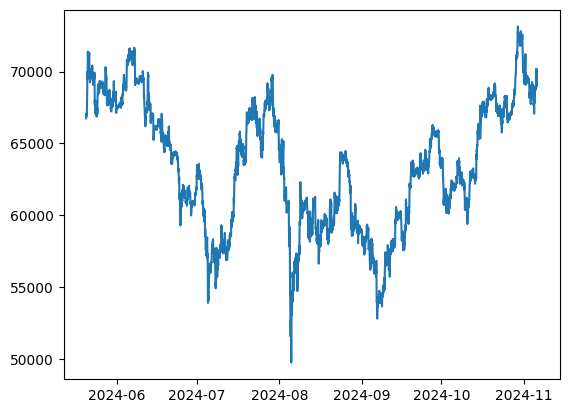

In [6]:
from preprocessing.utils import CreateTimeFrames
timeframes = ['15min', '1h','4h', '1d']

df_all_tf= CreateTimeFrames(df, timeframes)

df_tf = df_all_tf[FREQ]
df_tf = df_tf.iloc[-4072:,:]

import matplotlib.pyplot as plt
plt.plot(df_tf['close'])

In [7]:
import torch

In [8]:
close = df_tf['close'].to_numpy(dtype=np.float32)

In [9]:
!pip install PyWavelets
clear_output()

In [10]:
from preprocessing.denoising import wavelet_denoising

close_denoised = wavelet_denoising(close)

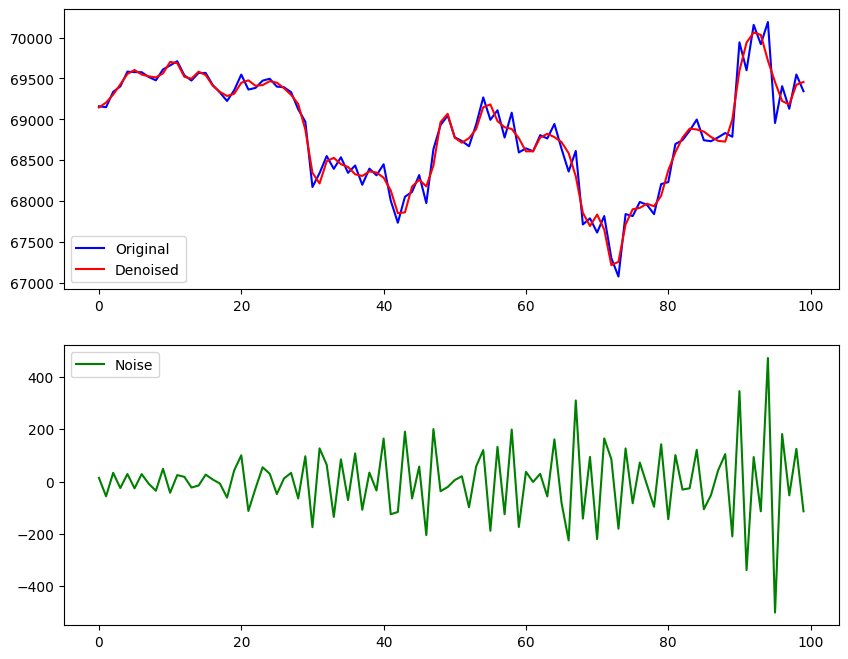

In [11]:
fig, axes = plt.subplots(2,1, figsize=(10,8))

axes[0].plot(close[-100:], color = 'blue', label = 'Original')
axes[0].plot(close_denoised[-100:], color = 'red', label = 'Denoised')
axes[0].legend()
axes[1].plot(close[-100:]-close_denoised[-100:], color = 'green', label = 'Noise')
axes[1].legend()
plt.show()

In [12]:
# train = close[:int(np.floor(TRAIN_SPLIT*len(close)))]
# val= close[int(np.floor(TRAIN_SPLIT*len(close))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
# test= close[int(np.floor((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]

# assert (train.size+val.size+test.size) == close.size, f"The dimension of price is dividable to SPLIT numbers. Splited len indicators is:{train.size+val.size+test.size} but df len is:{len(close)} "
# print(f'train size:{train.shape[0]}, val size:{val.shape[0]}, test size:{test.shape[0]}.')

In [13]:
# train_denoised = close_denoised[:int(np.floor(TRAIN_SPLIT*len(close)))]
# val_denoised= close_denoised[int(np.floor(TRAIN_SPLIT*len(close))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
# test_denoised= close_denoised[int(np.floor((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]

# assert (train_denoised.size+val_denoised.size+test_denoised.size) == close_denoised.size, f"The dimension of price is dividable to SPLIT numbers. Splited len indicators is:{train_denoised.size+val_denoised.size+test_denoised.size} but df len is:{len(close_denoised)} "
# print(f'train_denoised size:{train_denoised.shape[0]}, val_denoised size:{val_denoised.shape[0]}, test_denoised size:{test_denoised.shape[0]}.')

## Create Seq

In [14]:
def create_seq_x(data, seq_length):
  sequences = []
  for i in range(len(data) - seq_length):
    sequences.append(data[i:i + seq_length])
  return np.array(sequences, dtype=np.int64)

In [15]:
x_close_seq = create_seq_x(close, SEQ_LENGTH)
x_close_seq_denoised = create_seq_x(close_denoised, SEQ_LENGTH)

In [16]:
x_train = x_close_seq[:int(np.floor(TRAIN_SPLIT*len(x_close_seq)))]
x_val= x_close_seq[int(np.floor(TRAIN_SPLIT*len(x_close_seq))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(x_close_seq) ))]
x_test= x_close_seq[int(np.floor((TRAIN_SPLIT+VAL_SPLIT)*len(x_close_seq))):]

assert (len(x_train)+len(x_val)+len(x_test)) == len(x_close_seq), f"The dimension of price is dividable to SPLIT numbers. Splited len indicators is:{len(x_train)+len(x_val)+len(x_test)} but df len is:{len(x_close_seq)} "
print(f'x_train size:{x_train.shape[0]}, x_val size:{x_val.shape[0]}, x_test size:{x_test.shape[0]}.')

x_train size:2816, x_val size:403, x_test size:805.


In [17]:
x_train_denoised = x_close_seq_denoised[:int(np.floor(TRAIN_SPLIT*len(x_close_seq)))]
x_val_denoised= x_close_seq_denoised[int(np.floor(TRAIN_SPLIT*len(x_close_seq))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(x_close_seq) ))]
x_test_denoised= x_close_seq_denoised[int(np.floor((TRAIN_SPLIT+VAL_SPLIT)*len(x_close_seq))):]

assert (len(x_train_denoised)+len(x_val_denoised)+len(x_test_denoised)) == len(x_close_seq_denoised), f"The dimension of price is dividable to SPLIT numbers. Splited len indicators is:{len(x_train_denoised)+len(x_val_denoised)+len(x_test_denoised)} but df len is:{len(x_close_seq_denoised)} "
print(f'x_train_denoised size:{x_train_denoised.shape[0]}, x_val_denoised size:{x_val_denoised.shape[0]}, x_test_denoised size:{x_test_denoised.shape[0]}.')

x_train_denoised size:2816, x_val_denoised size:403, x_test_denoised size:805.


In [18]:
# x_train = create_seq_x(train, SEQ_LENGTH)
# x_val = create_seq_x(val, SEQ_LENGTH)
# x_test = create_seq_x(test, SEQ_LENGTH)

# x_train_denoised = create_seq_x(train_denoised, SEQ_LENGTH)
# x_val_denoised = create_seq_x(val_denoised, SEQ_LENGTH)
# x_test_denoised = create_seq_x(test_denoised, SEQ_LENGTH)

In [19]:
def create_seq_y(data, seq_len):
  out = np.zeros((len(data)-seq_len,1), dtype = np.float32)
  for i in range(1, len(data)-seq_len+1):
    out[i-1] = data[i+seq_len-1]
  return out

In [20]:
y_close_seq = create_seq_y(close, SEQ_LENGTH)
y_close_seq_denoised = create_seq_y(close_denoised, SEQ_LENGTH)


In [21]:
y_train = y_close_seq[:int(np.floor(TRAIN_SPLIT*len(y_close_seq)))]
y_val= y_close_seq[int(np.floor(TRAIN_SPLIT*len(y_close_seq))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(y_close_seq) ))]
y_test= y_close_seq[int(np.floor((TRAIN_SPLIT+VAL_SPLIT)*len(y_close_seq))):]

assert (len(y_train)+len(y_val)+len(y_test)) == len(y_close_seq), f"The dimension of price is dividable to SPLIT numbers. Splited len indicators is:{len(y_train)+len(y_val)+len(y_test)} but df len is:{len(y_close_seq)} "
print(f'y_train size:{y_train.shape[0]}, y_val size:{y_val.shape[0]}, y_test size:{x_test.shape[0]}.')

y_train size:2816, y_val size:403, y_test size:805.


In [22]:
y_train_denoised = y_close_seq_denoised[:int(np.floor(TRAIN_SPLIT*len(y_close_seq_denoised)))]
y_val_denoised= y_close_seq_denoised[int(np.floor(TRAIN_SPLIT*len(y_close_seq_denoised))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(y_close_seq_denoised) ))]
y_test_denoised= y_close_seq_denoised[int(np.floor((TRAIN_SPLIT+VAL_SPLIT)*len(y_close_seq_denoised))):]

assert (len(y_train_denoised)+len(y_val_denoised)+len(y_test_denoised)) == len(y_close_seq_denoised), f"The dimension of price is dividable to SPLIT numbers. Splited len indicators is:{len(y_train_denoised)+len(y_val_denoised)+len(y_test_denoised)} but df len is:{len(y_close_seq_denoised)} "
print(f'y_train_denoised size:{y_train_denoised.shape[0]}, y_val_denoised size:{y_val_denoised.shape[0]}, y_test_denoised size:{x_test_denoised.shape[0]}.')

y_train_denoised size:2816, y_val_denoised size:403, y_test_denoised size:805.


In [23]:
y_test[-1]

array([69343.], dtype=float32)

In [24]:
close[-1]

69343.0

In [25]:
# y_train = create_seq_y(train, SEQ_LENGTH)
# y_val = create_seq_y(val, SEQ_LENGTH)
# y_test = create_seq_y(test, SEQ_LENGTH)

# y_train_denoised = create_seq_y(train_denoised, SEQ_LENGTH)
# y_val_denoised = create_seq_y(val_denoised, SEQ_LENGTH)
# y_test_denoised = create_seq_y(test_denoised, SEQ_LENGTH)

In [26]:
print(f'x_train shape:{x_train.shape}, y_train shape:{y_train.shape}')
print(f'x_val shape:{x_val.shape}, y_val shape:{y_val.shape}')
print(f'x_test shape:{x_test.shape}, y_test shape:{y_test.shape}')

x_train shape:(2816, 48), y_train shape:(2816, 1)
x_val shape:(403, 48), y_val shape:(403, 1)
x_test shape:(805, 48), y_test shape:(805, 1)


In [27]:
print(f'x_train_denoised shape:{x_train_denoised.shape}, y_train_denoised shape:{y_train_denoised.shape}')
print(f'x_val_denoised shape:{x_val_denoised.shape}, y_val_denoised shape:{y_val_denoised.shape}')
print(f'x_test_denoised shape:{x_test_denoised.shape}, y_test_denoised shape:{y_test_denoised.shape}')

x_train_denoised shape:(2816, 48), y_train_denoised shape:(2816, 1)
x_val_denoised shape:(403, 48), y_val_denoised shape:(403, 1)
x_test_denoised shape:(805, 48), y_test_denoised shape:(805, 1)


In [28]:
def create_dataloader(x, y, batch_size = BATCH_SIZE, shuffle=False):
  dataset = torch.utils.data.TensorDataset(x, y)
  dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
  return dataloader

x_train = torch.tensor(x_train, dtype=torch.float32).unsqueeze(2)
y_train = torch.tensor(y_train, dtype=torch.float32)
x_val = torch.tensor(x_val, dtype=torch.float32).unsqueeze(2)
y_val = torch.tensor(y_val, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32).unsqueeze(2)
y_test = torch.tensor(y_test, dtype=torch.float32)

x_train_denoised = torch.tensor(x_train_denoised, dtype=torch.float32).unsqueeze(2)
y_train_denoised = torch.tensor(y_train_denoised, dtype=torch.float32)
x_val_denoised = torch.tensor(x_val_denoised, dtype=torch.float32).unsqueeze(2)
y_val_denoised = torch.tensor(y_val_denoised, dtype=torch.float32)
x_test_denoised = torch.tensor(x_test_denoised, dtype=torch.float32).unsqueeze(2)
y_test_denoised = torch.tensor(y_test_denoised, dtype=torch.float32)

train_loader = create_dataloader(x_train, y_train)
val_loader = create_dataloader(x_val, y_val)
test_loader = create_dataloader(x_test, y_test)

train_loader_denoised = create_dataloader(x_train_denoised, y_train_denoised)
val_loader_denoised = create_dataloader(x_val_denoised, y_val_denoised)
test_loader_denoised = create_dataloader(x_test_denoised, y_test_denoised)


#Models

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class cnn(nn.Module):
  def __init__(self, printtoggle, seq_len = SEQ_LENGTH):
    super().__init__()
    self.conv1 = nn.Conv1d(1, 64, kernel_size=3, padding=1)
    self.bn1 = nn.BatchNorm1d(64)
    self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
    self.bn2 = nn.BatchNorm1d(128)
    # self.linear = nn.Linear(in_features = 3840, out_features=seq_len)
    self.linear = nn.Linear(in_features = 1536, out_features=seq_len)


    self.print = printtoggle

  def forward(self, x):

    identity = x.squeeze()
    print(f'identity shape:{identity.shape}') if self.print else None

    print(f'input shape:{x.shape}') if self.print else None
    x = self.conv1(x.transpose(1,2))
    print(f'conv1 shape:{x.shape}') if self.print else None
    x = self.bn1(x)
    print(f'bn1 shape:{x.shape}') if self.print else None
    x = F.relu(x)
    # x = F.max_pool1d(x, kernel_size=2)
    x = F.avg_pool1d(x, kernel_size=2)
    print(f'maxpool1 shape:{x.shape}') if self.print else None

    x = self.conv2(x)
    print(f'conv2 shape:{x.shape}') if self.print else None
    x = self.bn2(x)
    print(f'bn2 shape:{x.shape}') if self.print else None
    x = F.relu(x)
    # x = F.max_pool1d(x, kernel_size=2)
    x = F.avg_pool1d(x, kernel_size=2)
    print(f'avgpool2 shape:{x.shape}') if self.print else None
    x = torch.flatten(x, start_dim=1)
    print(f'flatten shape:{x.shape}') if self.print else None
    x = self.linear(x)
    print(f'linear output shape:{x.shape}') if self.print else None
    # x = F.relu(x)

    x +=identity
    print(f'output shape:{x.shape}') if self.print else None

    return x

In [30]:
# x = next(iter(train_loader))
# nn = cnn(printtoggle=True)
# nn(x[0])

In [31]:
# cnn = cnn(in_channels=25, printtoggle=True)
# x_rand = torch.rand(2, 25, SEQ_LENGTH)
# cnn(x_rand)

##### cnn with def

In [32]:
# def create_cnn_model(printtoggle=False, in_channels = None, seq_len = SEQ_LENGTH):

#   class cnn(nn.Module):
#     def __init__(self, in_channels, printtoggle):
#       super().__init__()
#       self.conv1 = nn.Conv1d(in_channels, 64, kernel_size=3, padding=1)
#       # self.bn1 = nn.BatchNorm1d(64)
#       self.conv2 = nn.Conv1d(64, 128, kernel_size=5, padding=2)
#       # self.bn2 = nn.BatchNorm1d(128)
#       self.linear = nn.Linear(in_features = 3840, out_features=seq_len)

#       self.print = printtoggle

#     def forward(self, x):

#       print(f'input shape:{x.shape}') if self.print else None
#       x = self.conv1(x)
#       print(f'conv1 shape:{x.shape}') if self.print else None
#       x = F.relu(x)
#       x = F.max_pool1d(x, kernel_size=2)
#       print(f'maxpool1 shape:{x.shape}') if self.print else None

#       x = self.conv2(x)
#       print(f'conv2 shape:{x.shape}') if self.print else None
#       x = F.relu(x)
#       x = F.max_pool1d(x, kernel_size=2)
#       print(f'maxpool2 shape:{x.shape}') if self.print else None
#       x = torch.flatten(x, start_dim=1)
#       print(f'flatten shape:{x.shape}') if self.print else None
#       x = self.linear(x)
#       print(f'output shape:{x.shape}') if self.print else None
#       return x

#   model = cnn(in_channels=in_channels, printtoggle=printtoggle)


#   return model


## Continue coding

In [33]:
from xlstm import (
    xLSTMBlockStack,
    xLSTMBlockStackConfig,
    mLSTMBlockConfig,
    mLSTMLayerConfig,
    sLSTMBlockConfig,
    sLSTMLayerConfig,
    FeedForwardConfig,
)

def create_xlstm_model(seq_length=SEQ_LENGTH):
    # Define your input size, hidden size, and other relevant parameters
    input_size = 1  # Number of features in your time series
    embedding_dim = 32  # Dimension of the embeddings, reduced to save memory
    output_size = 1  # Number of output features (predicting the next value)

    # Define the xLSTM configuration
    cfg = xLSTMBlockStackConfig(
        mlstm_block=mLSTMBlockConfig(
            mlstm=mLSTMLayerConfig(
                conv1d_kernel_size=4, qkv_proj_blocksize=2, num_heads=2  # Reduced parameters to save memory
            )
        ),
        slstm_block=sLSTMBlockConfig(
            slstm=sLSTMLayerConfig(
                backend="cuda",
                num_heads=2,  # Reduced number of heads to save memory
                conv1d_kernel_size=2,  # Reduced kernel size to save memory
                bias_init="powerlaw_blockdependent",
            ),
            feedforward=FeedForwardConfig(proj_factor=1.1, act_fn="gelu"),  # Reduced projection factor to save memory
        ),
        context_length=seq_length,
        num_blocks=4,  # Reduced number of blocks to save memory
        embedding_dim=embedding_dim,
        slstm_at=[1],
    )


    # Instantiate the xLSTM stack
    xlstm_stack = xLSTMBlockStack(cfg).to("cuda")


    # Add a linear layer to project input data to the required embedding dimension
    input_projection = nn.Linear(input_size, embedding_dim).to("cuda")


    # Add a final linear layer to project the xLSTM output to the desired output size
    output_projection = nn.Linear(embedding_dim, output_size).to("cuda")


    return xlstm_stack, input_projection, output_projection

In [34]:
class ModelWrapper(nn.Module):
    def __init__(self, revin_layer, cnn_model, xlstm_stack, input_projection, output_projection, printtoggle=False):
        super().__init__()
        self.revin_layer = revin_layer
        self.cnn_model = cnn_model
        self.xlstm_stack = xlstm_stack
        self.input_projection = input_projection
        self.output_projection = output_projection

        self.print = printtoggle

    def forward(self, x):
        print(f'input shape is:{x.shape}') if self.print else None
        x = self.revin_layer(x, 'norm')
        print(f'revin shape is:{x.shape}') if self.print else None
        print(f"Shape before cnn_model: {x.shape}") if self.print else None
        x = self.cnn_model(x)
        print(f'cnn shape is:{x.shape}') if self.print else None
        x = x.unsqueeze(2)
        print(f'unsqueeze shape is:{x.shape}') if self.print else None
        x = self.input_projection(x)
        x = self.xlstm_stack(x)
        x = self.output_projection(x)
        print(f'after output projection shape is:{x.shape}') if self.print else None
        x = self.revin_layer(x, 'denorm')
        print(f'after denorm shape is:{x.shape}') if self.print else None
        return x

In [35]:
# MW = ModelWrapper(revin_layer, cnn_model, xlstm_stack, input_projection, output_projection, printtoggle=True).to('cuda')
# x_rand = torch.rand(16, 120, 1).to('cuda')
# MW(x_rand)

In [36]:
def batch_min_max_scaler(data, min_val=None, max_val=None):
    if min_val is None or max_val is None:
      min_val = data.min()
      max_val = data.max()

    scale = max_val - min_val
    scale[scale == 0] = 1.0 # set scale to 1 when all values are the same

    normalized_data = (data - min_val)/scale
    return normalized_data, scale, min_val

def batch_denorm(data, scale, min_val):
    return data * scale + min_val

In [37]:
import time
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.optim as optim
import numpy as np

def train_model(ModelWrapper, train_loader, val_loader, train_loader_denoised, val_loader_denoised):

    # Hyperparameters
    learning_rate = 0.001
    num_epochs = 200
    batch_size = 8

    the_best_model = {'Accuracy':0, 'best_net_state_dict':None, 'best_acc_epoch':int()}


    best_val_loss = float('inf')
    patience = 20
    trigger_times = 0

    # Define the loss function and optimiser
    criterion = nn.MSELoss()
    # parameters = list(revin_layer.parameters())+list(cnn_model.parameters())+list(xlstm_stack.parameters()) + list(input_projection.parameters()) + list(output_projection.parameters())
    parameters = list(ModelWrapper.parameters())
    optimiser = optim.Adam(parameters, lr=learning_rate)
    scheduler = ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=10)  # Learning rate scheduler

    initial_lr = optimiser.param_groups[0]['lr']
    lr_reduced = False # Flag to track if learning rate has been reduced

    SaveInfo = {
    'EpochLoss': np.zeros((num_epochs, 1), dtype=np.float32),
    'ValLoss': np.zeros((num_epochs, 1), dtype=np.float32)
}

    ModelWrapper = ModelWrapper.to('cuda')


    SaveInfo['TrainTime'] = time.time()
    # Training loop
    for epoch in range(num_epochs):

        BatchLoss = []
        ModelWrapper.train()

        for (batch_x, batch_y),(batch_x_denoised, batch_y_denoised) in zip(train_loader, train_loader_denoised) :

            batch_x = batch_x.to('cuda')
            batch_y = batch_y.to('cuda')
            batch_y_denoised = batch_y_denoised.to('cuda')
            batch_x_denoised = batch_x_denoised.to('cuda')

            # Forward pass
            yhat = ModelWrapper(batch_x_denoised)
            yhat = yhat[:,-1,:]

            batch_y_denoised, _, _ = batch_min_max_scaler(batch_y_denoised)
            yhat, _,_ = batch_min_max_scaler(yhat)

            # Ensure the shapes match
            # before_denorm = before_denorm.squeeze()
            yhat = yhat.squeeze()
            batch_y_denoised = batch_y_denoised.squeeze()

            # Compute the loss
            loss = criterion(yhat, batch_y_denoised)

            # Backward pass and optimization
            optimiser.zero_grad()
            loss.backward()
            # torch.nn.utils.clip_grad_norm_(ModelWrapper.parameters(), max_norm=1.0)  # Apply gradient clipping to prevent the exploding gradient problem
            optimiser.step()

            # Collecting batch history
            BatchLoss.append(loss.item())

            # Batch loop is over here




        # Validation step
        ModelWrapper.eval()

        val_loss = 0
        with torch.no_grad():
            for (batch_x, batch_y), (batch_x_denoised, batch_y_denoised) in zip(val_loader, val_loader_denoised):

                # batch_x_denoised
                batch_x = batch_x.to('cuda')
                batch_y = batch_y.to('cuda')
                batch_x_denoised = batch_x_denoised.to('cuda')
                # batch_y_denoised = batch_y_denoised.to('cuda')

                # Forward pass
                yhat = ModelWrapper(batch_x_denoised)
                # Get last output
                yhat = yhat[:,-1,:]

                batch_y, _, _ = batch_min_max_scaler(batch_y)
                yhat, _,_ = batch_min_max_scaler(yhat)

                # Ensure the shapes match
                # before_denorm = before_denorm.squeeze()
                yhat = yhat.squeeze()
                batch_y = batch_y.squeeze()

                # Compute the loss
                val_loss = criterion(yhat, batch_y)
                val_loss += val_loss.item()


        val_loss /= len(val_loader)
        scheduler.step(val_loss)  # Adjust learning rate based on validation loss
        SaveInfo['ValLoss'][epoch] = val_loss.cpu().numpy()
        SaveInfo['EpochLoss'][epoch] = np.mean(BatchLoss)


        # Print learning rate reduction only once
        if not lr_reduced and optimiser.param_groups[0]['lr'] < initial_lr:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Reducing learning rate to {optimiser.param_groups[0]["lr"]}')
            lr_reduced = True

        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {np.mean(BatchLoss):.8f}, Validation Loss: {val_loss.cpu().numpy():.8f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(ModelWrapper.state_dict(), f'/content/drive/MyDrive/results/{FILE_NAME}/cnnxlstm_{FREQ}.pt')
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print('Early stopping!')
                break

    print("Training complete!")

    return  SaveInfo

# -------------------------------------------------------------------------------------------
# Evaluation
# -------------------------------------------------------------------------------------------

def evaluate_model(ModelWrapper, test_X_denoised):

    test_X_denoised = test_X_denoised.to('cuda')
    # test_y = test_y.to('cuda')
    # Load the best model
    ModelWrapper.load_state_dict(torch.load(f'/content/drive/MyDrive/results/{FILE_NAME}/cnnxlstm_{FREQ}.pt'))

    ModelWrapper.eval()

    test_predictions = []
    with torch.no_grad():
        test_predictions = ModelWrapper(test_X_denoised)

    return test_predictions

In [ ]:
from RevIN.RevIN import RevIN
revin_layer = RevIN(num_features=1)

cnn_model = cnn(printtoggle=False)
xlstm_stack, input_projection, output_projection = create_xlstm_model()

In [39]:
model = ModelWrapper(revin_layer, cnn_model, xlstm_stack, input_projection, output_projection)
SaveInfo = train_model(model, train_loader, val_loader, train_loader_denoised, val_loader_denoised)

[8/8] c++ slstm.o slstm_forward.cuda.o slstm_backward.cuda.o slstm_backward_cut.cuda.o slstm_pointwise.cuda.o blas.cuda.o cuda_error.cuda.o -shared -L/usr/local/cuda/lib -lcublas -L/usr/local/lib/python3.10/dist-packages/torch/lib -lc10 -lc10_cuda -ltorch_cpu -ltorch_cuda -ltorch -ltorch_python -L/usr/local/cuda/lib64 -lcudart -o slstm_HS32BS8NH2NS4DBfDRbDWbDGbDSbDAfNG4SA1GRCV0GRC0d0FCV0FC0d0.so
Epoch [1/200], Loss: 0.16847146, Validation Loss: 0.02662829
Epoch [2/200], Loss: 0.10709467, Validation Loss: 0.02893010
Epoch [3/200], Loss: 0.08073761, Validation Loss: 0.02415099
Epoch [4/200], Loss: 0.07554328, Validation Loss: 0.02035612
Epoch [5/200], Loss: 0.06413989, Validation Loss: 0.01810597
Epoch [6/200], Loss: 0.05792690, Validation Loss: 0.01893920
Epoch [7/200], Loss: 0.05656842, Validation Loss: 0.01898695
Epoch [8/200], Loss: 0.04889566, Validation Loss: 0.01815379
Epoch [9/200], Loss: 0.04771423, Validation Loss: 0.01740417
Epoch [10/200], Loss: 0.04862597, Validation Loss: 0

In [40]:
# model = ModelWrapper(revin_layer, cnn_model, xlstm_stack, input_projection, output_projection)

# model.load_state_dict(torch.load(f'/content/drive/MyDrive/results/{FILE_NAME}/cnnxlstm_{FREQ}.pt'))

In [41]:
test_predictions = evaluate_model(model.to('cuda'), x_test_denoised.to('cuda'))

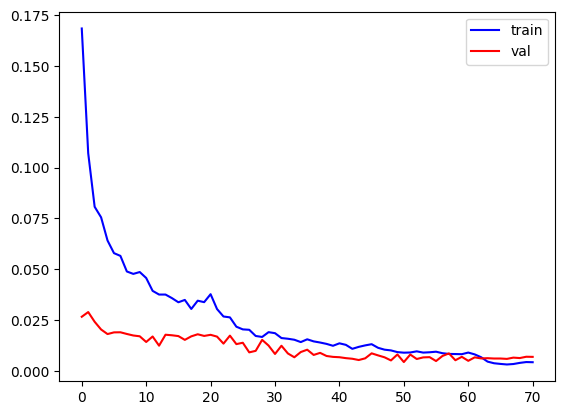

In [42]:
train_loss = SaveInfo.get('EpochLoss')
ind = np.where(SaveInfo.get('EpochLoss') == 0)[0][0]
plt.plot(train_loss[:ind], label='train', color='blue')
ValLoss = SaveInfo.get('ValLoss')
plt.plot(ValLoss[:ind], label='val', color='red')
plt.legend()
plt.show()

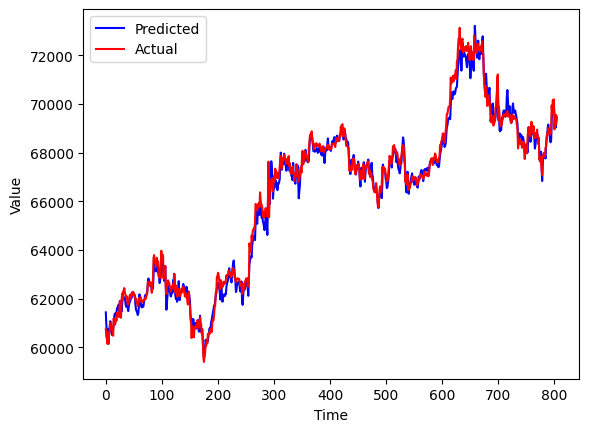

In [43]:
plt.plot(test_predictions[:,-1,:].squeeze().cpu().numpy(), color = 'blue', label='Predicted')
plt.plot(y_test.cpu().numpy(), color = 'red', label='Actual')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.show()

In [44]:
train_predictions = evaluate_model(model.to('cuda'), x_train_denoised.to('cuda'))
val_predictions = evaluate_model(model.to('cuda'), x_val_denoised.to('cuda'))

In [45]:
os.getcwd()

'/content/drive/MyDrive/xLSTM_v2/xlstm'

In [46]:
if isinstance(test_predictions, torch.Tensor):
    test_predictions = test_predictions.cpu().numpy()  # Convert PyTorch tensor to NumPy array
    train_predictions = train_predictions.cpu().numpy()
    val_predictions = val_predictions.cpu().numpy()

# Save the array
np.save(f'/content/drive/MyDrive/results/{FILE_NAME}/test_predictions.npy', test_predictions)
np.save(f'/content/drive/MyDrive/results/{FILE_NAME}/val_predictions.npy', val_predictions)
np.save(f'/content/drive/MyDrive/results/{FILE_NAME}/train_predictions.npy', train_predictions)


cnnxlstm_v9 (float32) | Train Accuracy: 67.53%
cnnxlstm_v9 (float32) | Validation Accuracy: 68.41%
cnnxlstm_v9 (float32) | Test Accuracy: 66.79%
cnnxlstm_v9 (float32) | Recall: 69.49%
cnnxlstm_v9 (float32) | Precision (Rise): 67.06%
cnnxlstm_v9 (float32) | Precision (Fall): 66.49%
cnnxlstm_v9 (float32) | F1 Score: 68.25%


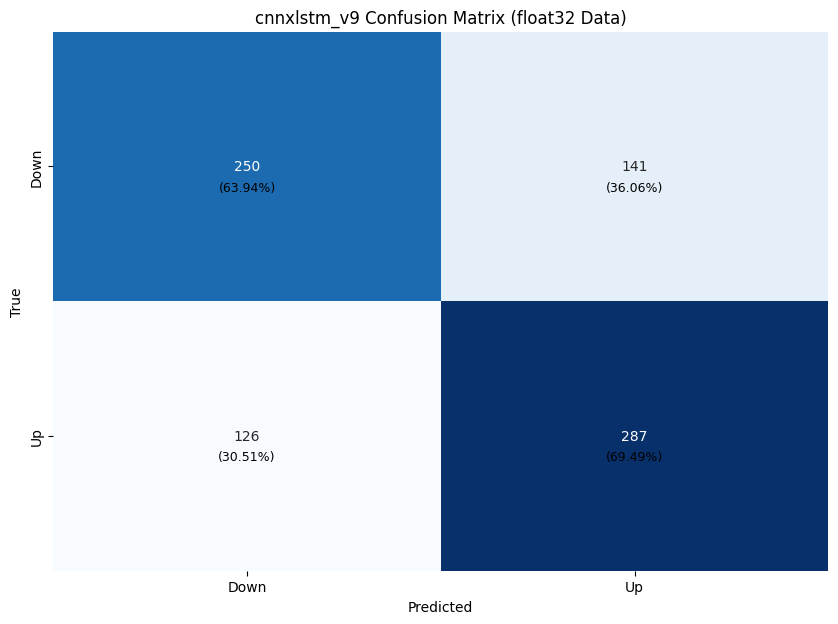

In [47]:
from direction_prediction.directional_prediction import evaluate_directional_movement
data_type = 'float32'
# true_labels, predicted_labels, metrics_direction = evaluate_directional_movement(y_train.cpu().numpy(), train_predictions[:,-1,:].cpu().numpy(), y_val.cpu().numpy(), val_predictions[:,-1,:].cpu().numpy(), y_test.cpu().numpy(), test_predictions[:,-1,:].cpu().numpy(), model_name=FILE_NAME, data_type=data_type, using_darts=False)
true_labels, predicted_labels, metrics_direction = evaluate_directional_movement(y_train, train_predictions[:,-1,:], y_val, val_predictions[:,-1,:], y_test, test_predictions[:,-1,:], model_name=FILE_NAME, data_type=data_type, using_darts=False)


In [48]:
%pip install darts
clear_output()

In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
from darts import TimeSeries
import numpy as np

# -------------------------------------------------------------------------------------------
# Forecasting metrics
#
# https://gist.github.com/bshishov/5dc237f59f019b26145648e2124ca1c9
# -------------------------------------------------------------------------------------------

def _naive_forecasting(actual: np.ndarray, seasonality: int = 1):
    # Naive forecasting method which just repeats previous samples
    return actual[:-seasonality]

def root_mean_squared_scaled_error(actual: np.ndarray, predicted: np.ndarray, seasonality: int = 1):
    # RMSSE - Root Mean Squared Scaled Error
    q = mean_squared_error(actual, predicted) / mean_squared_error(actual[seasonality:], _naive_forecasting(actual, seasonality))
    return np.sqrt(q)

def mean_absolute_scaled_error(actual: np.ndarray, predicted: np.ndarray, seasonality: int = 1):
    # MASE - Mean Absolute Scaled Error
    return mean_absolute_error(actual, predicted) / mean_absolute_error(actual[seasonality:], _naive_forecasting(actual, seasonality))

def calculate_metrics(actual, prediction, model_name, data_type):
    # Convert Darts TimeSeries to NumPy arrays if necessary
    if isinstance(actual, TimeSeries):
        actual = actual.values().flatten()
    if isinstance(prediction, TimeSeries):
        prediction = prediction.values().flatten()

    # Calculate metrics using scikit-learn functions
    metrics = {
        "MAE": mean_absolute_error(actual, prediction),
        "MSE": mean_squared_error(actual, prediction),
        "RMSE": root_mean_squared_error(actual, prediction),
        "RMSSE": root_mean_squared_scaled_error(actual, prediction),
        "MAPE": mean_absolute_percentage_error(actual, prediction) * 100,
        "MASE": mean_absolute_scaled_error(actual, prediction),
        "R2": r2_score(actual, prediction)
    }

    for metric_name, metric_value in metrics.items():
        value_str = f"{metric_value:.2f}"
        if metric_name == "MAPE":
            value_str += "%"
        print(f"{model_name} ({data_type}) | {metric_name}: {value_str}")

    return metrics

In [57]:
print("Shape of y_test:", y_test.shape)
print("Shape of test_predictions[:, -1, :]:", test_predictions[:, -1, :].shape)

Shape of y_test: torch.Size([805, 1])
Shape of test_predictions[:, -1, :]: (805, 1)


In [58]:
metrics_price = calculate_metrics(y_test.cpu().numpy(), test_predictions[:,-1,:], FILE_NAME, data_type)

cnnxlstm_v9 (float32) | MAE: 244.47
cnnxlstm_v9 (float32) | MSE: 99322.56
cnnxlstm_v9 (float32) | RMSE: 315.15
cnnxlstm_v9 (float32) | RMSSE: 1.07
cnnxlstm_v9 (float32) | MAPE: 0.37%
cnnxlstm_v9 (float32) | MASE: 1.24
cnnxlstm_v9 (float32) | R2: 0.99
